# **AI-Powered Workforce Analytics & Talent Intelligence Dashboard**

## **Data Cleaning and Exploratory Data Analysis (EDA)**
### Infosys Springboard Virtual Internship

**Project Module:** Data Cleaning & Exploratory Data Analysis

**Team Role:** Data Cleaning, Data Quality Assessment, Feature Analysis and Exploratory Data Analysis

______________________________________________________________________________
### Project Objective

The objective of this notebook is to prepare workforce data for AI-driven workforce analytics by performing data cleaning, data quality assessment, exploratory data analysis (EDA), feature relationship analysis, and generating insights that support employee attrition prediction and workforce intelligence.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/Workforce_Analytics_Dashboard"
IMAGE_DIR = os.path.join(BASE_DIR, "Images")

os.makedirs(IMAGE_DIR, exist_ok=True)

## 1. Import Libraries and Load Dataset

The required Python libraries are imported for data manipulation, visualization, and analysis. The workforce dataset is then loaded from Google Drive for further preprocessing and analysis.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
df = pd.read_csv("/content/drive/MyDrive/Workforce_Analytics_Dashboard/DATASET.csv")

In [ ]:
df_original = df.copy()

## 2. Dataset Preview

The first few records of the dataset are displayed to understand the available workforce attributes and verify that the dataset has been loaded successfully.

In [ ]:
#display first few records of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


The dataset contains **employee-related information** such as Age, Department, Job Role, Monthly Income, working hours, Overtime, Satisfaction, and Attrition.

## Dataset Information

The dataset information provides details about the number of records, feature names, data types, and memory usage. This helps verify the structure of the dataset before preprocessing.

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

The dataset contains 1470 rows and 35 columns. There are 26 columns are of integer datatype and 9 columns are of object.There is no null values present in the dataset.

## Statistical Summary

Descriptive statistics are generated to understand the central tendency, spread, and distribution of numerical workforce attributes.

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 3. Data Cleaning

Data cleaning is performed to improve data quality before analysis and machine learning. The process includes checking data types, missing values, duplicate records, invalid values, inconsistent categories, unnecessary columns, and outliers.

In [ ]:
#check data types
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
#Check inconsistent categorical values
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())
    print("-"*40)

Attrition
['Yes' 'No']
----------------------------------------
BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
----------------------------------------
Department
['Sales' 'Research & Development' 'Human Resources']
----------------------------------------
EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
----------------------------------------
Gender
['Female' 'Male']
----------------------------------------
JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
----------------------------------------
MaritalStatus
['Single' 'Married' 'Divorced']
----------------------------------------
Over18
['Y']
----------------------------------------
OverTime
['Yes' 'No']
----------------------------------------


Inconsistent values are not found.

In [ ]:
# check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


No missing values were present in the dataset.


In [ ]:
#check for duplicate data
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.


In [ ]:
#find unique values
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


Columns like Employee_count,Over18, and StandardHours has only one unique value.

Remove Unnecessary Columns

EmployeeCount, Over18, StandardHours columns contain constant values or unique identifiers that are not useful for analysis.So we remove this columns because they do not provide meaningful information for analysis.

In [ ]:
#remove unnecessary columns
df.drop(columns=["EmployeeCount","Over18","StandardHours"],inplace=True)

In [ ]:
df.shape

(1470, 32)

In [ ]:
#Check for invalid values
df[df["Age"] < 18]
df[df["MonthlyIncome"] < 0]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


No invalid values are found.


# **Detect Outliers**
Identify extreme values (outliers) in numerical columns that may affect data analysis and machine learning model performance.
Outliers are unusually high or low values compared to the rest of the data. They can:

Influence statistical measures such as the mean.
Affect visualization results.
Reduce the performance of machine learning models.
Represent data entry errors or genuine extreme observations.

Therefore, detecting outliers helps us understand the data better and decide whether they should be retained or treated.

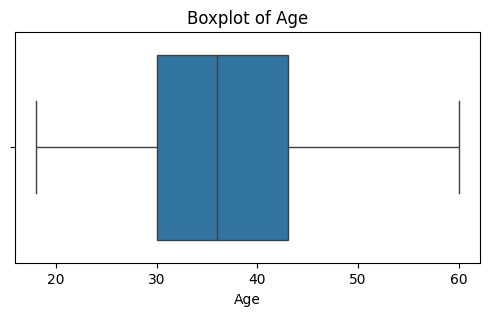

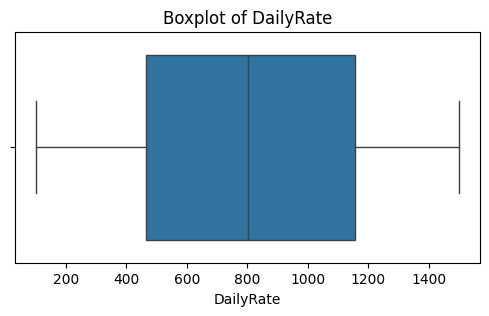

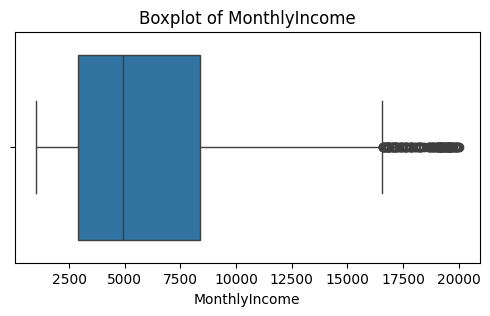

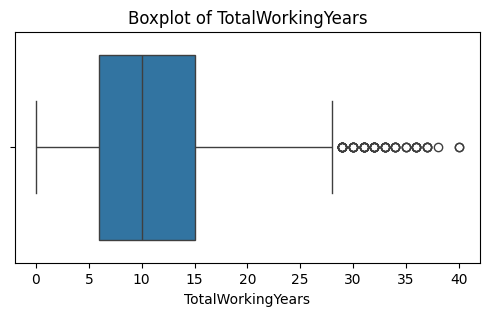

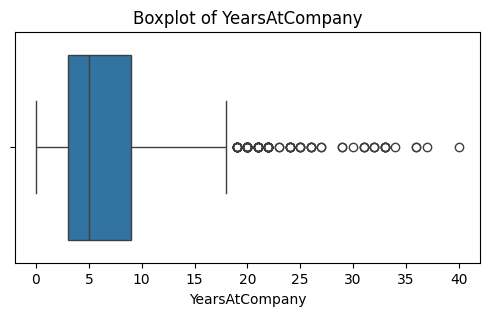

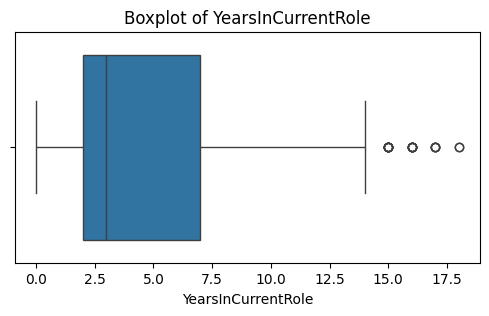

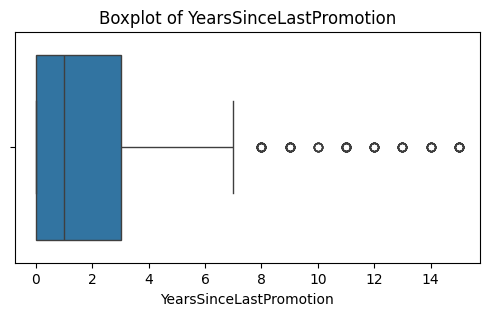

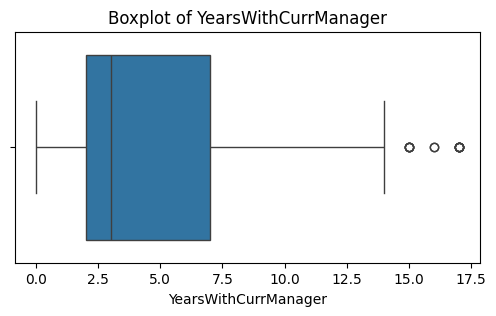

In [ ]:
columns = ["Age", "DailyRate", "MonthlyIncome",
           "TotalWorkingYears", "YearsAtCompany","YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Observation**

After plotting the boxplots:

Age: Few or no significant outliers

DailyRate: No major outliers.

MonthlyIncome: Several high-income values appear as outliers.

TotalWorkingYears: Some employees have considerably more experience than others.

YearsAtCompany: A few employees have worked much longer than the majority.

YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager have very few outliers.

These values are expected in an employee dataset and may represent senior or highly experienced employees rather than incorrect data.

# **Outlier Treatment**
After analyzing the numerical features using the IQR method and boxplots, I observed that the detected outliers represented genuine employee information, such as higher salaries, greater work experience, and longer tenure, rather than data entry errors. Since these values reflect real workforce characteristics, I decided not to perform IQR capping or remove the outliers. Keeping the original values preserves the integrity of the dataset


# **4. Save the clean dataset.**

In [ ]:
df.to_csv("/content/drive/MyDrive/Workforce_Analytics_Dashboard/cleaned_dataset.csv",index=False)

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


# **Data Quality Assessment**
The dataset was assessed during the Data Cleaning phase.

The following activities were completed:

- Missing value analysis
- Duplicate record verification
- Data type validation
- Constant column removal
- Identifier column removal
- Outlier detection

The cleaned dataset was used for all subsequent exploratory analysis.

# **5. Exploratory Data Analysis (EDA)**

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the cleaned workforce dataset, identify trends and patterns, analyze relationships among employee attributes, and generate business insights that support workforce analytics, talent intelligence, and predictive modeling.

**Summary Statistics**

Obtain descriptive statistics to understand the distribution of numerical and categorical variables.

In [ ]:
# Summary statistics for numerical features
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Summary statistics for categorical features
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,1233,1043,961,606,882,326,673,1054


**Observation**

The dataset contains employee demographic and organizational information.
Numerical features such as Age, MonthlyIncome, and TotalWorkingYears show varying distributions.
Categorical variables include Department, JobRole, Gender, BusinessTravel, and Attrition.

# **Feature Relationships (Univariate Analysis)**
Univariate Analysis is performed to analyze one variable at a time. It helps understand the distribution, frequency, and characteristics of individual employee attributes within the workforce dataset.

# **5.1 Analyze Target Variable (Attrition)**

Analyze the distribution of employees who stayed and those who left the organization.

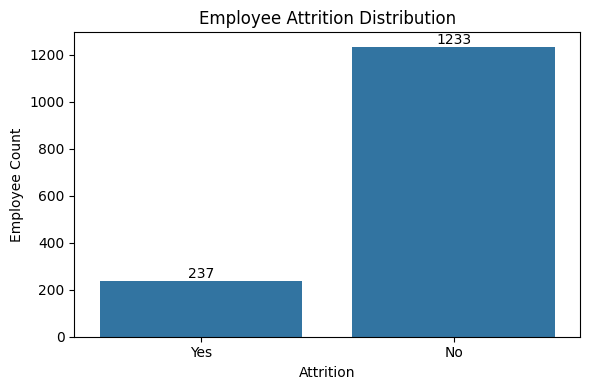

In [ ]:
#Employee Attrition Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Attrition', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition_Distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


**Observation**

- After analyzing the attrition distribution, I observed that 1,233 employees (83.88%) remained with the organization, while 237 employees (16.12%) left the company.
- Employee retention is significantly higher than attrition, indicating a relatively stable workforce.
- Although the attrition rate is lower than the retention rate, it is still significant enough to require further analysis of the factors influencing employee turnover.

**Business Insight**

Employee attrition is a key HR metric that reflects workforce stability. Analyzing attrition helps HR identify the factors affecting employee retention and supports data-driven decisions to improve employee engagement and reduce turnover.

**Conclusion**

The organization has a strong employee retention rate of approximately 84%. However, the 16% attrition rate highlights the need to analyze workforce factors and implement effective employee retention strategies.

# **5.2 Age Distribution**
To analyze the distribution of employee ages within the organization and identify the predominant age groups in the workforce.

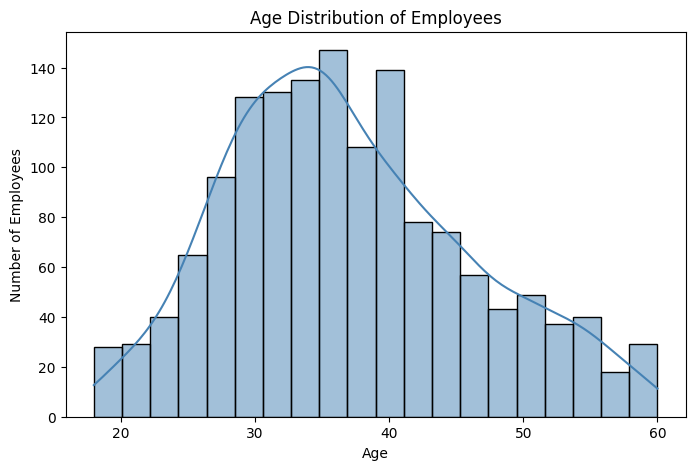

,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


In [ ]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

df["Age"].describe()

**Observation**

- After analyzing the age distribution, I observed that most employees are between 30–40 years, indicating a predominantly mid-career workforce.
- Employee ages range from 18 to 60 years, with fewer employees below 25 years and above 55 years.
- The workforce is well distributed, with a higher concentration of experienced employees.

**Business Insight**

The organization has a stable and experienced workforce. HR can use these insights for succession planning, leadership development, and targeted recruitment of young talent.

**Conclusion**

The age distribution reflects a balanced workforce, helping HR make informed decisions on workforce planning, career development, and talent management.

In [ ]:
print(f"Average Age : {df['Age'].mean():.2f}")
print(f"Median Age  : {df['Age'].median()}")
print(f"Minimum Age : {df['Age'].min()}")
print(f"Maximum Age : {df['Age'].max()}")

Average Age : 36.92
Median Age  : 36.0
Minimum Age : 18
Maximum Age : 60


# **5.3 Gender Distribution**

**Objective**

To analyze the gender composition of employees within the organization and understand workforce diversity.

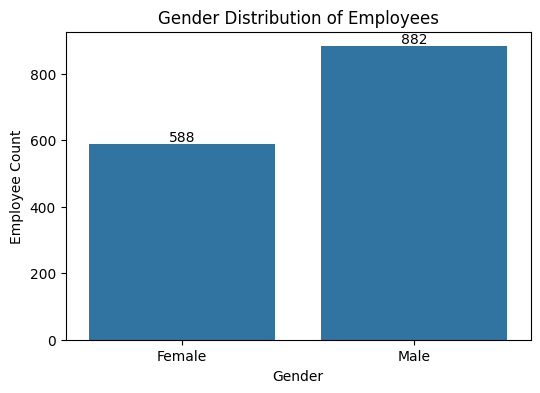

,count
Gender,
Male,882
Female,588


In [ ]:
#Gender Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Gender',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution of Employees")
plt.xlabel("Gender")
plt.ylabel("Employee Count")

plt.show()

df["Gender"].value_counts()

In [ ]:
#percentage
gender_percentage = (df["Gender"].value_counts(normalize=True) * 100).round(2)
print(gender_percentage)

Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64


**Observation**

- After analyzing the gender distribution, I observed that the workforce consists of 882 male employees (60%) and 588 female employees (40%).
- Male employees represent the majority of the workforce, while female employees also have a significant presence.
- The distribution indicates representation from both genders, reflecting a reasonably balanced workforce.

**Business Insight**

Gender distribution is an important indicator of workforce diversity. HR can use this analysis to monitor gender representation across departments and job roles and support Diversity, Equity, and Inclusion (DEI) initiatives.

**Conclusion**

The organization has representation from both male and female employees, with a higher proportion of male employees. Monitoring gender diversity helps HR develop more inclusive workforce planning and recruitment strategies.

# **5.4 Department-wise Employee Distribution**

Objective

To analyze the distribution of employees across different organizational departments and identify the departments with the highest workforce representation.

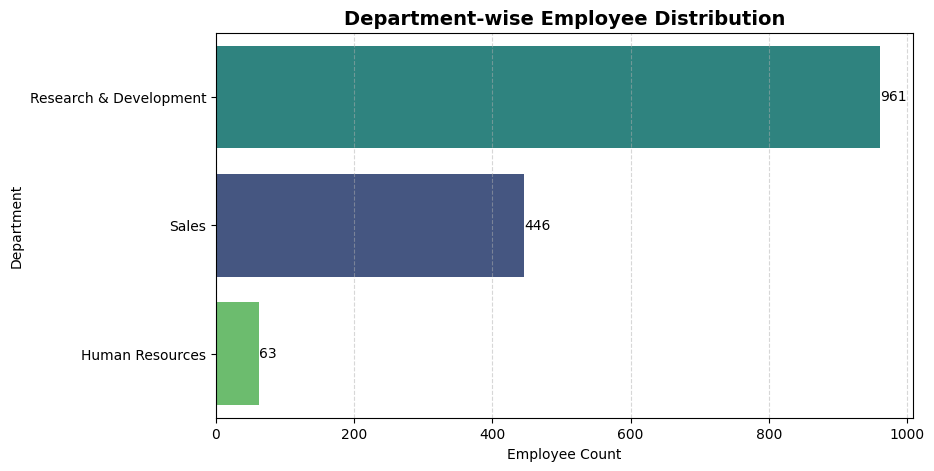

Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64


In [ ]:
#Identify the distribution of employees across departments.
plt.figure(figsize=(9,5))

ax = sns.countplot(
    y='Department',
    data=df,
    order=df['Department'].value_counts().index,
    hue='Department',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Department-wise Employee Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Employee Count")
plt.ylabel("Department")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

#percentage
department_percentage = (df["Department"].value_counts(normalize=True) * 100).round(2)
print(department_percentage)

**Observation**

- After analyzing the department distribution, I observed that employees are distributed across Research & Development, Sales, and Human Resources.
- The Research & Development department has the largest workforce with 961 employees (65.37%), followed by Sales with 446 employees (30.34%).
- The Human Resources department has the smallest workforce with 63 employees (4.29%), indicating a much smaller operational size.

**Business Insight**

The majority of employees are concentrated in the Research & Development department, highlighting its importance to the organization's core business operations. Department-wise workforce analysis helps HR plan recruitment, allocate resources efficiently, and monitor departmental performance.

**Conclusion**

The workforce is primarily concentrated in the Research & Development department, followed by Sales and Human Resources. These insights provide a strong foundation for further analysis of department-wise attrition and workforce planning.


#**5.6 Job Role Distribution**

**Objective**

To analyze the distribution of employees across different job roles and identify the roles with the highest workforce representation. This analysis helps understand workforce composition and supports talent management and resource planning.


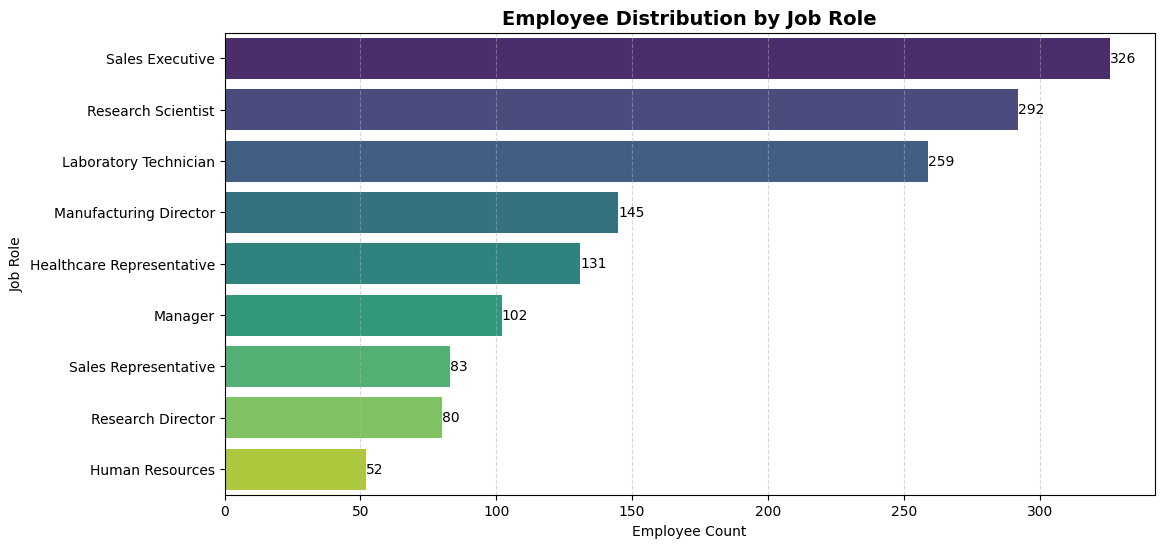

JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources               3.54
Name: proportion, dtype: float64


In [ ]:
#Job Role Distribution
plt.figure(figsize=(12,6))

ax = sns.countplot(
    y='JobRole',
    data=df,
    order=df['JobRole'].value_counts().index,
    hue='JobRole',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Distribution by Job Role", fontsize=14, fontweight='bold')
plt.xlabel("Employee Count")
plt.ylabel("Job Role")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

df["JobRole"].value_counts()

#job role percentage
jobrole_percentage = (df["JobRole"].value_counts(normalize=True) * 100).round(2)
print(jobrole_percentage)

**Observation**

- After analyzing the job role distribution, I observed that employees are spread across nine different job roles.
- Sales Executive (326), Research Scientist (292), and Laboratory Technician (259) are the most common job roles, indicating that these are the organization's key operational positions.
- Roles such as Human Resources (52), Research Director (80), and Sales Representative (83) have comparatively fewer employees.

**Business Insight**

The workforce is primarily concentrated in sales and research-oriented roles, highlighting their importance to the organization's operations. HR can use this analysis to support workforce planning, prioritize recruitment, and strengthen retention strategies for critical job roles.

**Conclusion**

The job role distribution shows that the organization relies heavily on a few key operational roles. These insights provide a foundation for analyzing job role-wise attrition and planning future workforce requirements.

# **5.7 Education Level Distribution**
**Objective**

To analyze the educational qualifications of employees and understand the overall educational profile of the workforce.

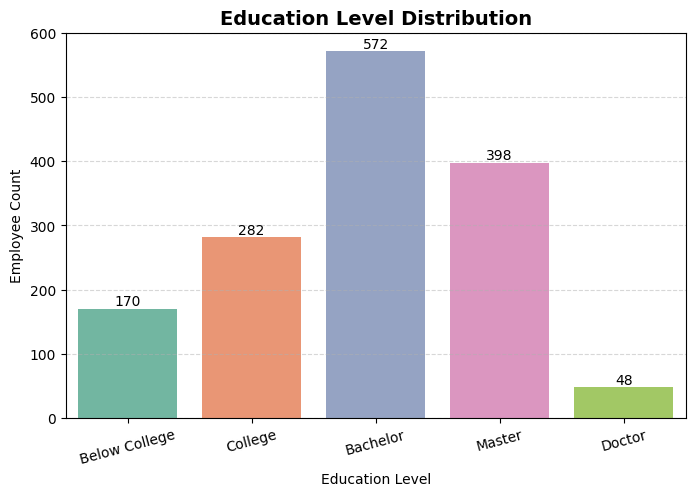

Education
1    11.56
2    19.18
3    38.91
4    27.07
5     3.27
Name: proportion, dtype: float64


In [ ]:
from matplotlib.colors import Normalize
#Education Level Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Education',
    data=df,
    order=sorted(df['Education'].unique()),
    hue='Education',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

# Replace numeric codes with labels
education_labels = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

plt.xticks(
    ticks=range(5),
    labels=[education_labels[i] for i in sorted(df['Education'].unique())],
    rotation=15
)

plt.title("Education Level Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Education Level")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

education_level_percentage=(df["Education"].value_counts(normalize=True)*100).round(2).sort_index()
print(education_level_percentage)

**Observation**

- After analyzing the education distribution, I observed that employees have educational qualifications ranging from Below College to Doctorate level.
- The majority of employees hold a Bachelor's degree (572), followed by Master's degree holders (398).
- Employees with a Doctorate degree (48) represent the smallest group within the organization.

**Business Insight**

The workforce is primarily composed of employees with undergraduate and postgraduate qualifications, indicating a skilled and knowledgeable talent pool. HR can use these insights to align recruitment, training, and career development programs with organizational needs.

**Conclusion**

The organization has a well-qualified workforce, with most employees holding Bachelor's and Master's degrees. This educational profile supports effective workforce planning and long-term organizational growth.

#**5.8 Business Travel Distribution**
**Objective**

To analyze the frequency of business travel among employees and understand travel patterns within the organization.

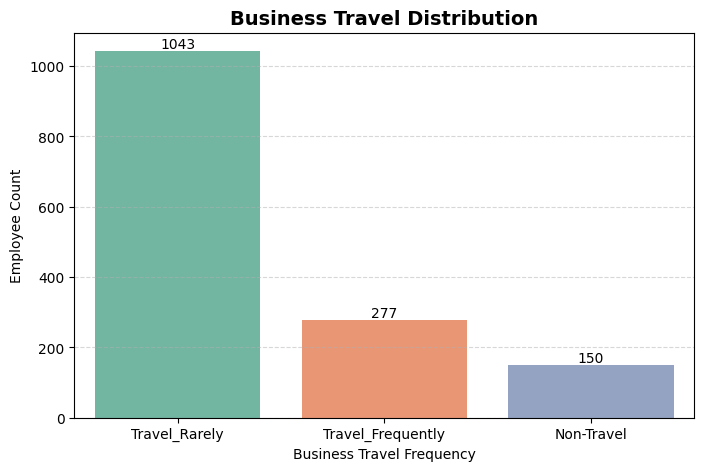

BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64


In [ ]:
#Business Travel Distribution
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='BusinessTravel',
    data=df,
    order=df['BusinessTravel'].value_counts().index,
    hue='BusinessTravel',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Business Travel Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Business Travel Frequency")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

business_travel= (df["BusinessTravel"].value_counts(normalize=True)*100).round(2)
print(business_travel)

**Observation**

- After analyzing the business travel distribution, I observed that employees are classified into Travel_Rarely, Travel_Frequently, and Non-Travel categories.
- The majority of employees (1,043) belong to the Travel_Rarely category, while 277 employees travel frequently and 150 employees do not travel.
- The analysis indicates that most employees undertake occasional business travel rather than frequent travel.

**Business Insight**

Business travel patterns can influence employee satisfaction, work-life balance, and overall well-being. HR can further analyze business travel alongside attrition to determine whether travel frequency contributes to employee turnover and to develop appropriate travel policies.

**Conclusion**

The workforce is primarily composed of employees who travel occasionally for business. These insights help HR evaluate travel requirements and support employee well-being and retention strategies.

#**5.9 Overtime Distribution**
**Objective**

To analyze the distribution of employees who work overtime and understand the prevalence of overtime within the organization.

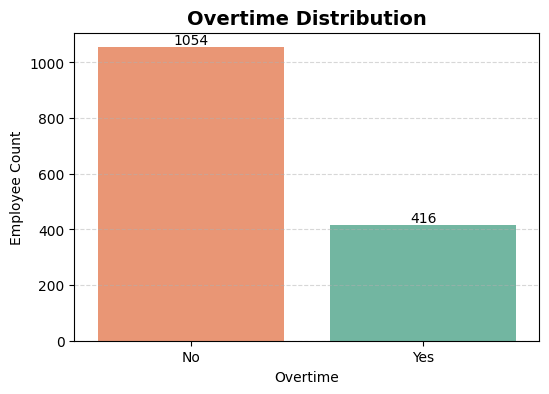

OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64


In [ ]:
#Overtime Distribution Analysis
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='OverTime',
    data=df,
    order=df['OverTime'].value_counts().index,
    hue='OverTime',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Overtime Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

overtime_percentage=(df["OverTime"].value_counts(normalize=True)*100).round(2)
print(overtime_percentage)

**Observation**

- After analyzing the overtime distribution, I observed that 1,054 employees (71.7%) do not work overtime, while 416 employees (28.3%) perform overtime.
- The majority of employees follow regular working hours, with a smaller proportion working overtime.
- The presence of a significant overtime group indicates that workload may vary across different roles and departments.

**Business Insight**

Overtime is an important workforce indicator that can influence employee well-being, work-life balance, and job satisfaction. HR can further analyze overtime with attrition to identify whether employees working overtime are more likely to leave the organization.

**Conclusion**

Most employees work within regular working hours, while a considerable proportion perform overtime. These insights help HR monitor workload distribution and develop strategies to improve employee well-being and retention.

# **5.10 Work-Life Balance Distribution**
**Objective**

To analyze employees' work-life balance ratings and understand how employees perceive the balance between their professional and personal lives.

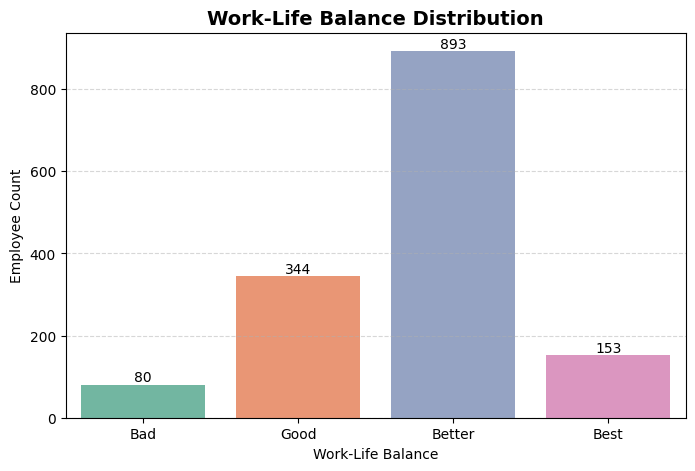

WorkLifeBalance
1     5.44
2    23.40
3    60.75
4    10.41
Name: proportion, dtype: float64


In [ ]:
#worklife balance analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

ax = sns.countplot(
    x='WorkLifeBalance',
    data=df,
    order=sorted(df['WorkLifeBalance'].unique()),
    hue='WorkLifeBalance',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['WorkLifeBalance'].unique())]
)

plt.title("Work-Life Balance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Work-Life Balance")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#percentage
worklife_balance_percentage=(df["WorkLifeBalance"].value_counts(normalize=True)*100).round(2).sort_index()
print(worklife_balance_percentage)

**Observation**

- After analyzing the work-life balance distribution, I observed that most employees (893) rated their work-life balance as Better, followed by Good (344) and Best (153).
- Only 80 employees reported a Bad work-life balance, representing the smallest group.
- The analysis suggests that the majority of employees perceive a satisfactory balance between their work and personal life.

**Business Insight**

Work-life balance is an important factor influencing employee satisfaction, productivity, and retention. HR can further analyze employees with poor work-life balance to identify potential risks related to stress, burnout, and attrition.

**Conclusion**

The workforce generally reports a positive work-life balance, indicating a healthy work environment. These insights help HR strengthen employee well-being initiatives and improve long-term retention.

# **5.11 Monthly Income Distribution**

**Objective**

To analyze the distribution of employees' monthly income and identify salary patterns within the organization.

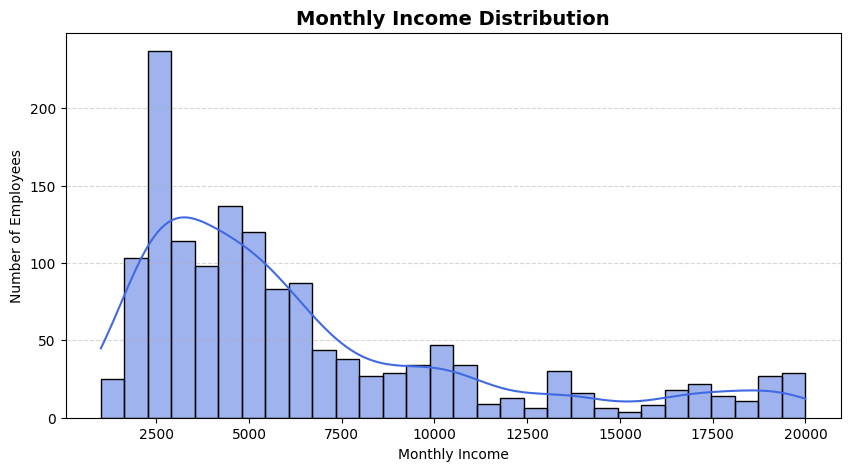

,MonthlyIncome
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


In [ ]:
#analyze employee salary
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='MonthlyIncome',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Monthly Income Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

df["MonthlyIncome"].describe()

In [ ]:
#Statistics
print(f"Average Monthly Income : {df['MonthlyIncome'].mean():.2f}")
print(f"Median Monthly Income  : {df['MonthlyIncome'].median():.2f}")
print(f"Minimum Monthly Income : {df['MonthlyIncome'].min()}")
print(f"Maximum Monthly Income : {df['MonthlyIncome'].max()}")

Average Monthly Income : 6502.93
Median Monthly Income  : 4919.00
Minimum Monthly Income : 1009
Maximum Monthly Income : 19999


**Observation**

- After analyzing the monthly income distribution, I observed that employee salaries range from approximately ₹1,000 to ₹16,500.
- Most employees earn between ₹2,000 and ₹6,000, while the number of employees gradually decreases as income increases.
- The right-skewed distribution indicates that only a small proportion of employees belong to the higher salary range.

**Business Insight**

Monthly income is an important factor influencing employee satisfaction and retention. HR can further analyze monthly income alongside attrition to identify whether compensation levels impact employee turnover and to support fair compensation planning.

**Conclusion**

The organization's salary distribution is concentrated in the lower and middle income ranges, with fewer employees in higher salary brackets. These insights support compensation analysis and help HR make informed decisions regarding employee retention and salary planning.

# **5.12 Job Satisfaction Distribution**

**Objective**

To analyze employees' job satisfaction levels and understand overall employee satisfaction within the organization.

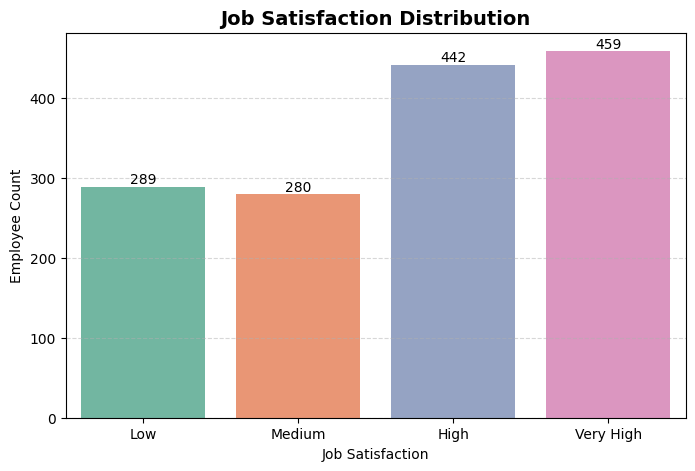

JobSatisfaction
1    19.66
2    19.05
3    30.07
4    31.22
Name: proportion, dtype: float64


In [ ]:
#job satisfaction analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ax = sns.countplot(
    x='JobSatisfaction',
    data=df,
    order=sorted(df['JobSatisfaction'].unique()),
    hue='JobSatisfaction',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['JobSatisfaction'].unique())]
)

plt.title("Job Satisfaction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#percentage of jobsatisfaction
job_satisfaction_percentage=(df["JobSatisfaction"].value_counts(normalize=True)*100).round(2).sort_index()
print(job_satisfaction_percentage)

**Observation**

- After analyzing the job satisfaction distribution, I observed that the majority of employees reported High or Very High job satisfaction.
- Very High job satisfaction was the most common rating (459 employees), followed by High (442 employees).
- A smaller group of employees reported Low (289) and Medium (280) job satisfaction, indicating opportunities to improve employee experience.

**Business Insight**

Job satisfaction is a key indicator of employee engagement and retention. HR can further analyze employees with lower job satisfaction alongside attrition, overtime, and work-life balance to identify factors affecting employee retention.

**Conclusion**

The organization demonstrates a positive job satisfaction profile, with most employees reporting high satisfaction levels. These insights help HR strengthen employee engagement initiatives and improve long-term retention.

#**5.13 Environment Satisfaction Distribution**

**Objective**

To analyze employees' satisfaction with their work environment and understand workplace conditions within the organization.

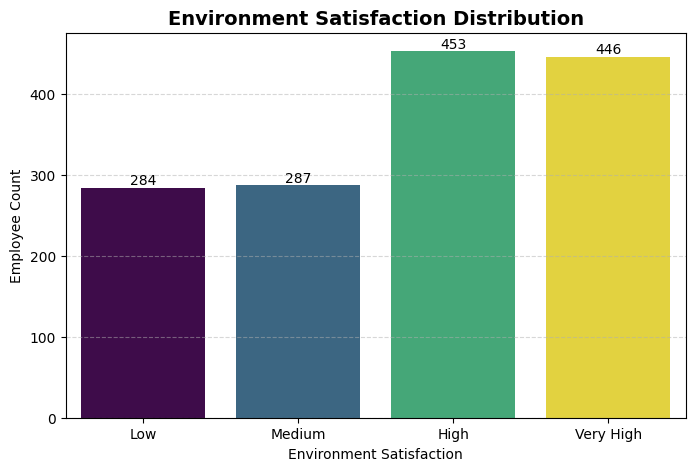

EnvironmentSatisfaction
1    19.32
2    19.52
3    30.82
4    30.34
Name: proportion, dtype: float64


In [ ]:
#Environment Satisfaction Analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ax = sns.countplot(
    x='EnvironmentSatisfaction',
    data=df,
    order=sorted(df['EnvironmentSatisfaction'].unique()),
    hue='EnvironmentSatisfaction',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['EnvironmentSatisfaction'].unique())]
)

plt.title("Environment Satisfaction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Environment Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

environment_satisfaction_percentage=(df["EnvironmentSatisfaction"].value_counts(normalize=True)*100).round(2).sort_index()
print(environment_satisfaction_percentage)

**Observation**

- After analyzing the environment satisfaction distribution, I observed that the majority of employees reported High or Very High satisfaction with their work environment.
- High environment satisfaction was the most common rating (453 employees), followed closely by Very High (446 employees).
- A smaller group of employees reported Medium (287) and Low (284) satisfaction, indicating opportunities to enhance the workplace experience.

**Business Insight**

Environment satisfaction is an important factor influencing employee engagement, productivity, and retention. HR can further analyze employees with lower satisfaction levels to identify workplace improvements and reduce the risk of employee turnover.

**Conclusion**

The organization maintains a generally positive work environment, with most employees expressing high satisfaction. These insights help HR strengthen workplace engagement initiatives and improve the overall employee experience.

# **6. Bivariate Analysis**
**Objective**

Bivariate Analysis is performed to examine the relationship between two variables. It helps identify factors influencing employee attrition, workforce performance, and employee engagement, enabling HR teams to make data-driven decisions.

#**6.1 Attrition vs Overtime**

**Objective**

To examine the relationship between overtime work and employee attrition and determine whether employees who work overtime are more likely to leave the organization.



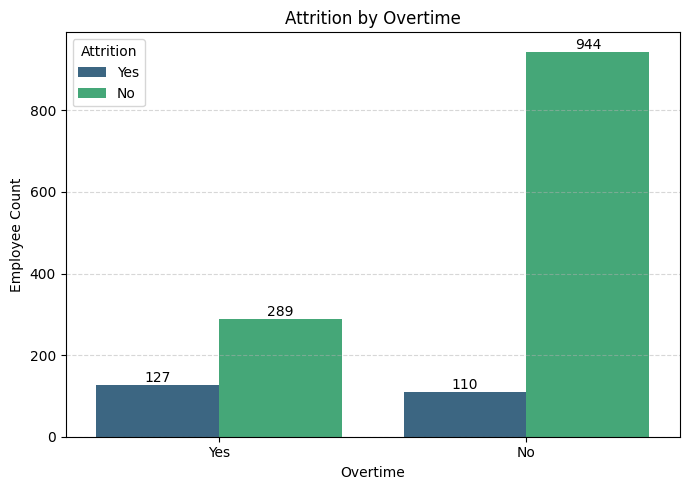

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


In [ ]:
#analyze whether employees who work overtime are more likely to leave the organization.
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Overtime.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

#percentage of attrition rate
attrition_rate = (
    pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
).round(2)

print(attrition_rate)

**Observation**

- After analyzing the relationship between overtime and attrition, I observed that employees working overtime have a higher attrition rate than those who do not work overtime.
- Among employees working overtime, 127 left the organization, compared to 110 employees who left among those not working overtime.
- The analysis suggests that overtime may be associated with an increased likelihood of employee turnover.

**Business Insight**

The findings indicate that overtime is a potential factor influencing employee attrition. HR can monitor overtime patterns and implement effective workload management strategies to improve employee well-being and reduce employee turnover.

**Conclusion**

Employees working overtime appear to be more likely to leave the organization than those with regular working hours. Managing overtime effectively can help improve employee satisfaction and strengthen retention.

# **6.2 Attrition vs Department**

**Objective**

To analyze employee attrition across different departments and identify departments with higher employee turnover.

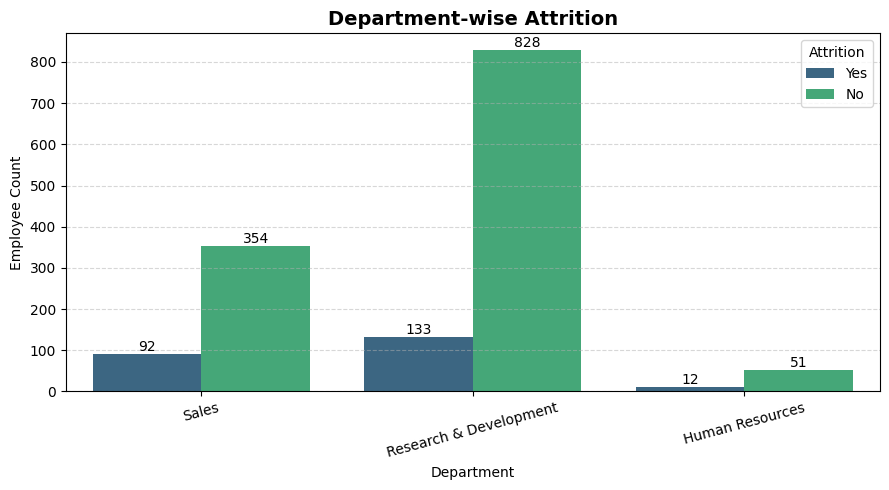

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [ ]:
#Analyze attrition vs department
plt.figure(figsize=(9,5))

ax = sns.countplot(
    x='Department',
    hue='Attrition',
    data=df,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Department-wise Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Department.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

# Crosstab
department_attrition = pd.crosstab(df['Department'], df['Attrition'])
print(department_attrition)


In [ ]:
#percentage Table
#Attrition percentage
print(" ")
print("Percentage")
department_attrition_rate = (
    pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
).round(2)

print(department_attrition_rate)

 
Percentage
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


**Observation**

- After analyzing the relationship between department and attrition, I observed that employees from all three departments experienced attrition.
- The Research & Development department recorded the highest number of employee exits (133), followed by Sales (92) and Human Resources (12).
- Since Research & Development has the largest workforce, it also records the highest number of attrition cases.

**Business Insight**

Department-wise attrition analysis helps HR identify areas that require targeted retention strategies. Comparing attrition rates within each department can provide deeper insights into workforce stability and support better resource planning.

**Conclusion**

Employee attrition exists across all departments, with the highest number of exits observed in Research & Development. Further department-wise analysis can help HR develop effective retention and workforce planning strategies.

# **6.3 Attrition vs Business Travel**
**Objective**

To analyze the relationship between business travel frequency and employee attrition.

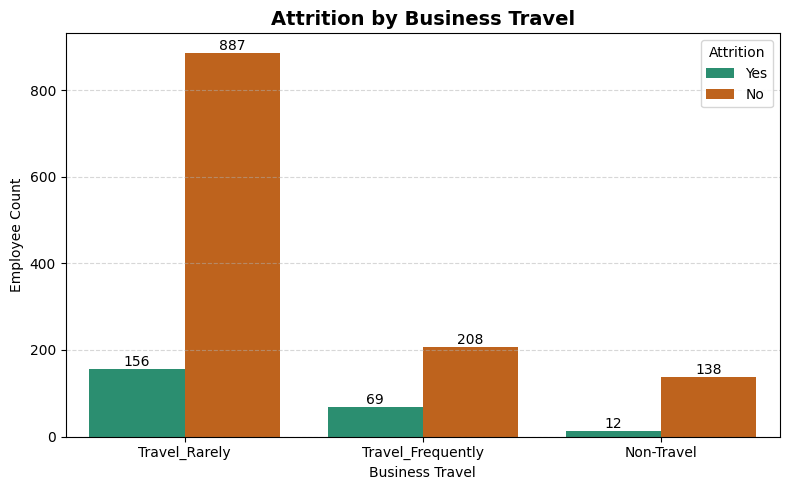

Attrition           No  Yes
BusinessTravel             
Non-Travel         138   12
Travel_Frequently  208   69
Travel_Rarely      887  156


In [ ]:
#attrition vs business travel
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='BusinessTravel',
    hue='Attrition',
    data=df,
    palette='Dark2'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Business Travel", fontsize=14, fontweight='bold')
plt.xlabel("Business Travel")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Business_Travel.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

business_travel_attrition = pd.crosstab(df['BusinessTravel'], df['Attrition'])
print(business_travel_attrition)

In [ ]:
#percentage table
business_travel_attrition_rate = (
    pd.crosstab(
        df['BusinessTravel'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

print(business_travel_attrition_rate)

Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


**Observation**

- After analyzing the relationship between business travel and attrition, I observed that employees in the Travel_Rarely category recorded the highest number of attrition cases (156), followed by Travel_Frequently (69) and Non-Travel (12).
- Since Travel_Rarely has the largest workforce, it also records the highest number of employee exits.
- The analysis suggests that attrition is present across all business travel categories, and a percentage-based comparison would provide a more accurate assessment of attrition risk.

**Business Insight**

Business travel can influence employee well-being and work-life balance. HR can compare attrition rates across travel categories to determine whether frequent travel is associated with higher employee turnover and to develop appropriate employee support and travel policies.

**Conclusion**

Employee attrition is observed across all business travel categories. Further analysis using attrition percentages can help HR better understand the impact of business travel on employee retention and workforce planning.

# **6.4 Attrition vs Job Satisfaction**

**Objective**

To analyze the relationship between job satisfaction and employee attrition and determine whether employees with lower job satisfaction are more likely to leave the organization.

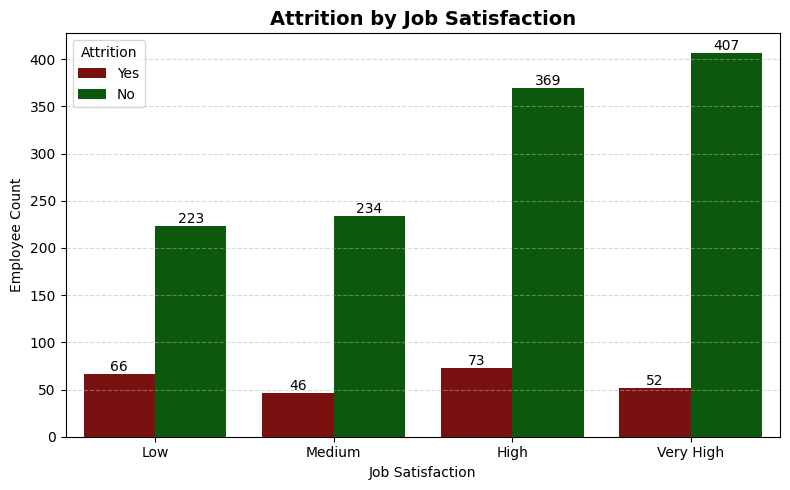

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [ ]:
#Attrition vs Job Satisfaction Analysis
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    hue_order=['Yes', 'No'],
    data=df,
    palette=['#8B0000', '#006400']
)

for container in ax.containers:
    ax.bar_label(container)

labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['JobSatisfaction'].unique())]
)

plt.title("Attrition by Job Satisfaction", fontsize=14, fontweight='bold')
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Job_Satisfaction.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

pd.crosstab(df['JobSatisfaction'], df['Attrition'])

In [ ]:
#percentage table
job_satisfaction_rate = (
    pd.crosstab(
        df['JobSatisfaction'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

print(job_satisfaction_rate)

Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33


**Observation**

- After analyzing the relationship between job satisfaction and attrition, I observed that attrition is present across all job satisfaction levels.
- The High job satisfaction category recorded the highest number of employee exits (73), followed by Low (66), Very High (52), and Medium (46).
- Since each satisfaction level has a different number of employees, a percentage-based comparison would provide a more accurate understanding of the relationship between job satisfaction and attrition.

**Business Insight**

Job satisfaction is an important factor influencing employee engagement and retention. HR can analyze attrition rates across satisfaction levels to identify employees at higher risk of leaving and implement targeted engagement and career development initiatives.

**Conclusion**

Employee attrition is observed across all job satisfaction levels. Further analysis using attrition percentages can help HR better understand the impact of job satisfaction on employee retention and support effective workforce management.

#**6.5 Attrition vs Work-Life Balance**

**Objective**

To analyze the relationship between employees' work-life balance and attrition, and identify whether poor work-life balance contributes to employee turnover.

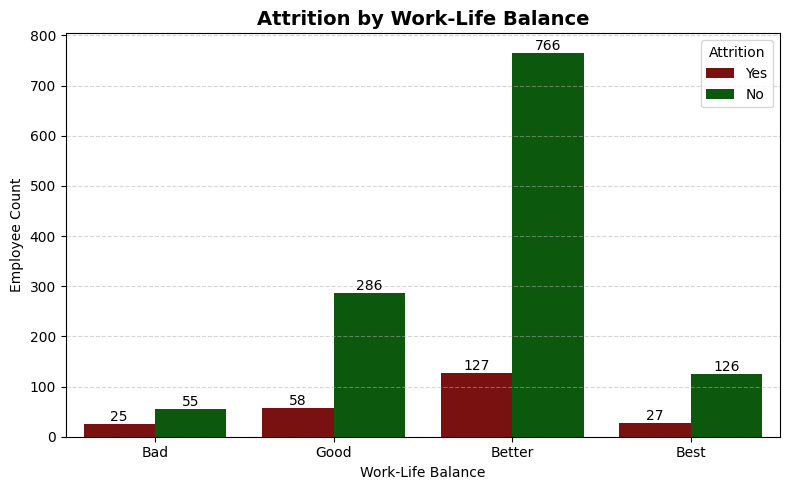

Attrition,No,Yes
Bad,55,25
Good,286,58
Better,766,127
Best,126,27


In [ ]:
#Attrition vs Work-Life Balance Analysis
plt.figure(figsize=(8,5))

labels = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

ax = sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    hue_order=['Yes', 'No'],
    data=df,
    palette=['#8B0000', '#006400']
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(
    ticks=range(4),
    labels=[labels[i] for i in sorted(df['WorkLifeBalance'].unique())]
)

plt.title("Attrition by Work-Life Balance", fontsize=14, fontweight='bold')
plt.xlabel("Work-Life Balance")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Work-Life_Balance.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

#count table
wlb_table = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition']
)

wlb_table.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

display(wlb_table)

In [ ]:
#percentage of worklife balance
wlb_rate = (
    pd.crosstab(
        df['WorkLifeBalance'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

wlb_rate.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

display(wlb_rate)

Attrition,No,Yes
Bad,68.75,31.25
Good,83.14,16.86
Better,85.78,14.22
Best,82.35,17.65


**Observation**

- After analyzing the relationship between work-life balance and attrition, I observed that employee attrition is present across all work-life balance categories.
- The Better work-life balance category recorded the highest number of employee exits (127), followed by Good (58), Best (27), and Bad (25).
- Since the Better category has the largest workforce, a percentage-based comparison would provide a more accurate understanding of attrition across different work-life balance levels.

**Business Insight**

Work-life balance plays an important role in employee well-being and retention. HR can compare attrition rates across work-life balance categories to identify employees at higher risk of leaving and implement initiatives that promote employee wellness and engagement.

**Conclusion**

Employee attrition is observed across all work-life balance categories. Further analysis using attrition percentages can help HR better understand the relationship between work-life balance and employee retention.

#**6.6 Attrition vs Monthly Income**

**Objective**

To analyze the relationship between employees' monthly income and attrition, and determine whether compensation influences employee retention.

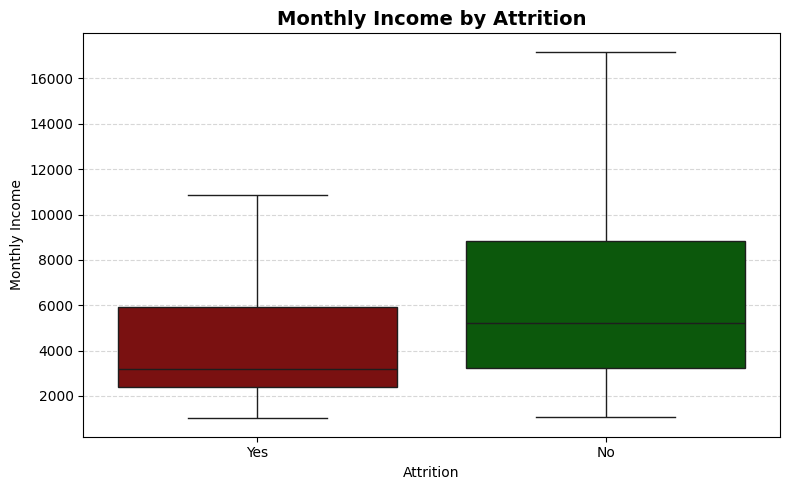

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [ ]:
#Attrition vs Monthly Income Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    hue='Attrition',
    palette=['#8B0000', '#006400'],
    legend=False,
    showfliers=False
)

plt.title("Monthly Income by Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Monthly_Income.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

df.groupby('Attrition')['MonthlyIncome'].describe()

**Observation**

- After analyzing the relationship between monthly income and attrition, I observed that employees who left the organization generally have a lower median monthly income than those who remained.
- Employees who stayed show a wider salary distribution, indicating greater variation in income across different job roles and experience levels.
- A few high-income outliers are present in both groups, suggesting that attrition occurs across different salary levels, although it appears more common among lower-income employees.

**Business Insight**

Monthly income is an important factor that may influence employee retention. HR can further analyze compensation alongside attrition to identify salary ranges with higher turnover and develop competitive compensation and retention strategies.

**Conclusion**

The analysis suggests a relationship between monthly income and employee attrition, with lower-income employees showing a greater tendency to leave the organization. These insights can support compensation planning and employee retention initiatives.

#**6.7 Attrition vs Age**

**Objective**

To analyze the relationship between employees' age and attrition and determine whether age influences employee retention.

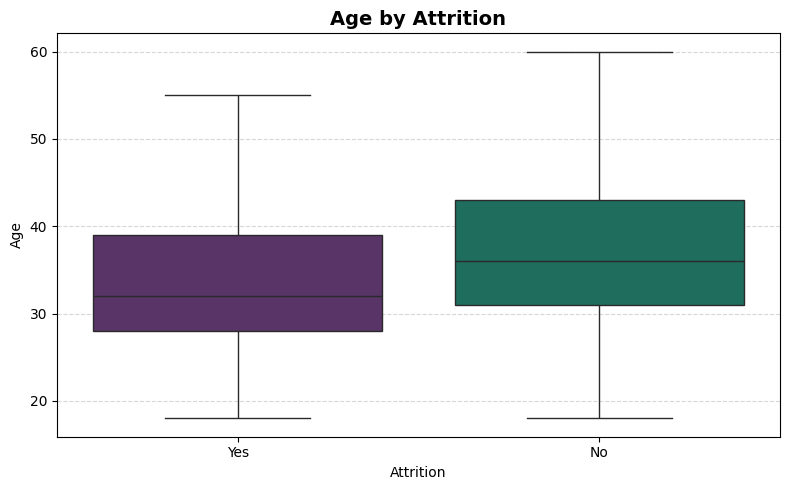

In [ ]:
#Attrition vs Age Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df,
    hue='Attrition',
    palette=['#5B2C6F', '#117A65'],   # Purple & Teal
    legend=False,
    showfliers=False
)

plt.title("Age by Attrition", fontsize=14, fontweight='bold')
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Age.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
#statistical summary
age_summary = df.groupby('Attrition')['Age'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(age_summary)

,count,mean,median,min,max,std
Attrition,,,,,,
No,1233,37.561233,36.0,18,60,8.88836
Yes,237,33.607595,32.0,18,58,9.68935


**Observation**

- After analyzing the relationship between age and attrition, I observed that employees who left the organization generally have a lower median age than those who remained.
- The age distribution of retained employees is slightly wider, indicating greater variation across different age groups.
- The analysis suggests that attrition is relatively more common among younger employees, although it is observed across all age groups.

**Business Insight**

Age can influence employee retention, particularly during the early stages of a career. HR can focus on career development, mentorship, and growth opportunities for younger employees to improve long-term retention.

**Conclusion**

The analysis suggests a relationship between employee age and attrition, with younger employees showing a higher tendency to leave the organization. These insights can support workforce planning and employee retention strategies.

#**6.8 Attrition vs Gender**

**Objective**

To analyze the relationship between employee gender and attrition and determine whether attrition varies between male and female employees.

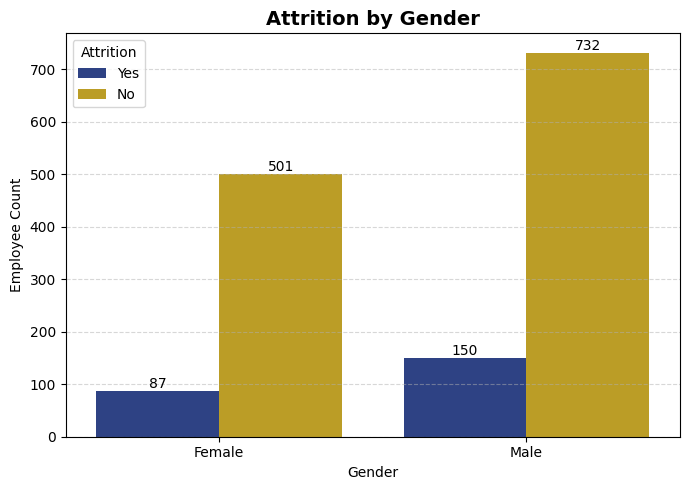

In [ ]:
#Attrition vs Gender Analysis
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Gender',
    hue='Attrition',
    data=df,
    hue_order=['Yes', 'No'],
    palette=['#1F3A93', '#D4AC0D']
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Attrition by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Employee Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Attrition vs Gender.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
#count table
gender_table = pd.crosstab(
    df['Gender'],
    df['Attrition']
)

display(gender_table)

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [ ]:
#percentage
gender_rate = (pd.crosstab(df['Gender'],df['Attrition'],normalize='index') * 100).round(2)

display(gender_rate)

Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,82.99,17.01


**Observation**

After analyzing the relationship between gender and attrition, I observed that attrition is present among both male and female employees.
- Male employees recorded 150 attrition cases, while female employees recorded 87 attrition cases.
- Since the organization has a larger male workforce, a percentage-based comparison is required to accurately evaluate the impact of gender on attrition.

**Business Insight**

Gender-wise attrition analysis helps HR evaluate workforce diversity and employee retention across different groups. Comparing attrition rates by gender can help determine whether targeted retention initiatives are needed.

**Conclusion**

Employee attrition is observed among both male and female employees. Further analysis using attrition percentages can provide a clearer understanding of whether gender influences employee retention.

#**6.9 Correlation Analysis**

**Objective**

To identify relationships between numerical features and understand how different employee attributes are correlated with each other, supporting feature selection and workforce analytics.

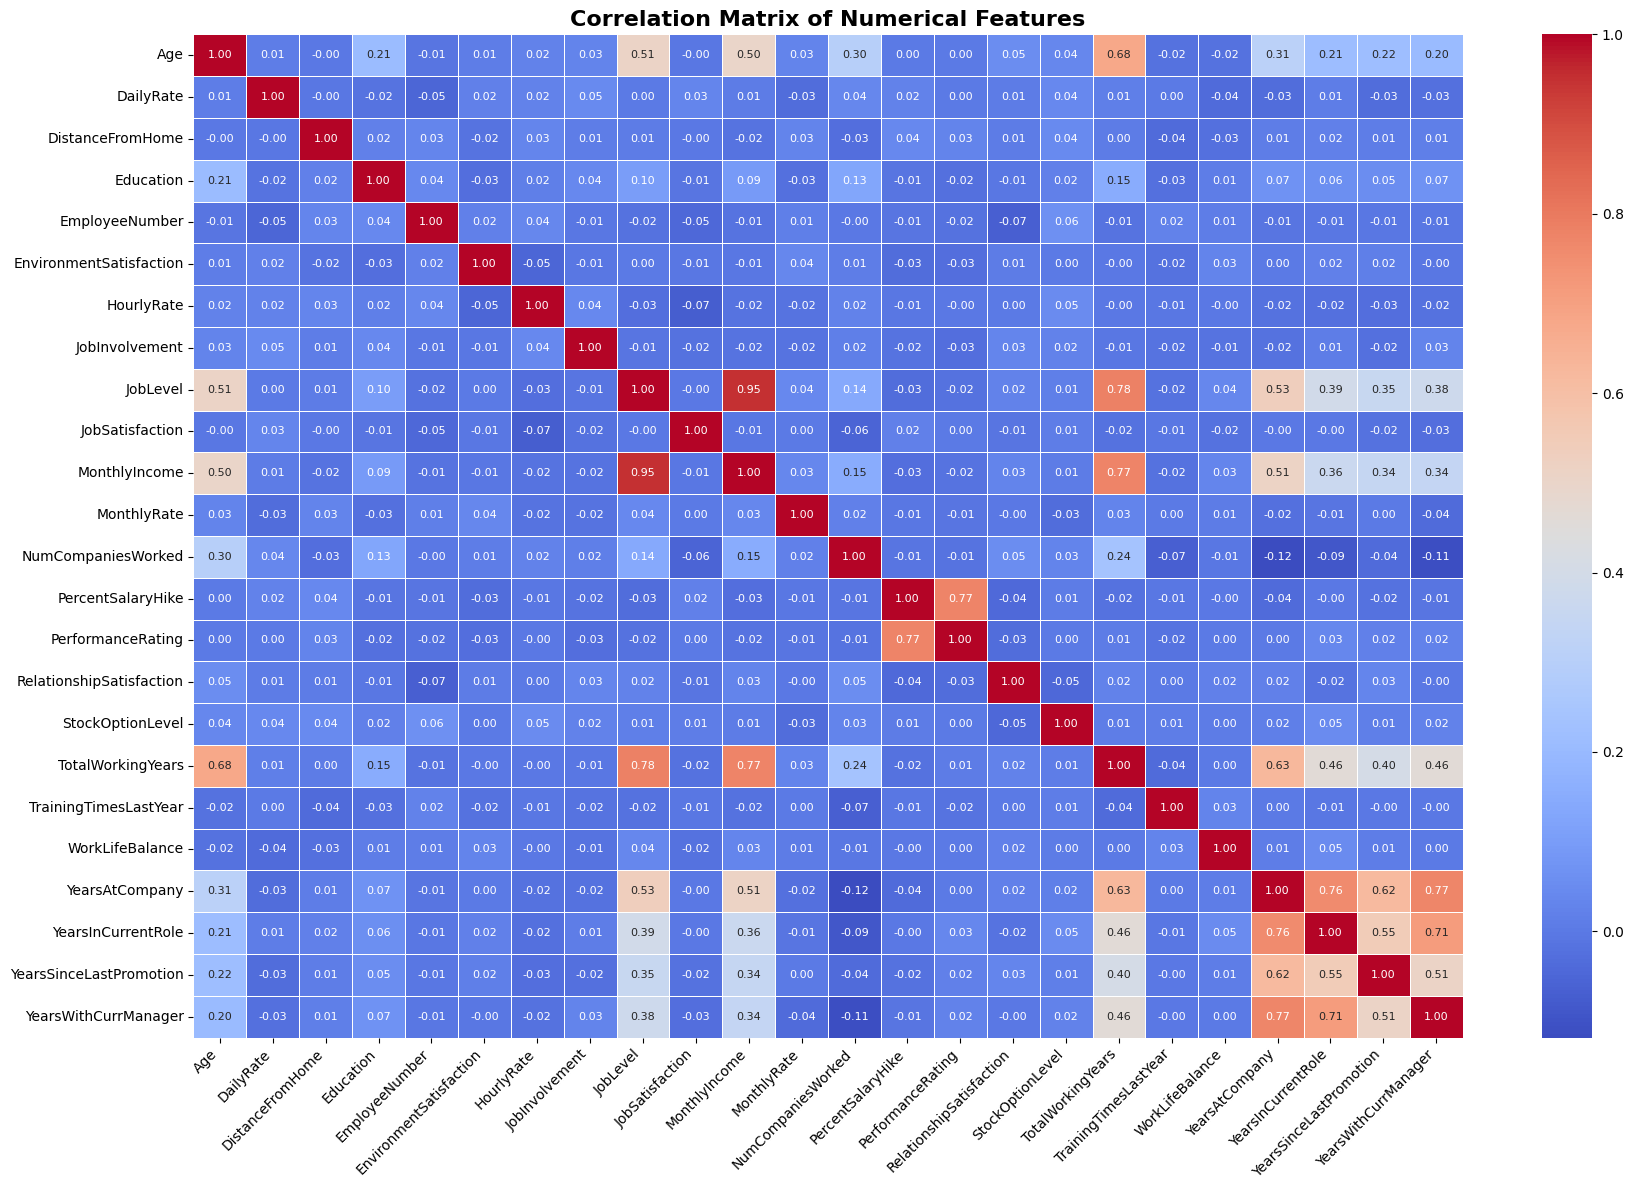

In [ ]:
#correlation matrix
plt.figure(figsize=(18,12))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Correlation Matrix of Numerical Features",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "Correlation_Matrix.png"),
            dpi=300,
            bbox_inches="tight")
plt.show()

In [ ]:
#Top Correlated Features
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs.sort_values(
    ascending=False,
    key=abs
)

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs.head(20)

,,0
JobLevel,MonthlyIncome,0.950300
MonthlyIncome,JobLevel,0.950300
JobLevel,TotalWorkingYears,0.782208
TotalWorkingYears,JobLevel,0.782208
PerformanceRating,PercentSalaryHike,0.773550
PercentSalaryHike,PerformanceRating,0.773550
MonthlyIncome,TotalWorkingYears,0.772893
TotalWorkingYears,MonthlyIncome,0.772893
YearsWithCurrManager,YearsAtCompany,0.769212
YearsAtCompany,YearsWithCurrManager,0.769212


- After analyzing the correlation heatmap, I observed that most numerical features have weak to moderate correlations, indicating that they contribute unique information to the analysis.
- Job Level and Monthly Income show the strongest positive correlation (0.95), suggesting that employees at higher job levels generally earn higher salaries.
- Total Working Years is strongly correlated with Job Level (0.78) and Monthly Income (0.77), while Years at Company has a strong relationship with Years with Current Manager (0.77) and Years in Current Role (0.76), reflecting expected career progression within the organization.

**Business Insight**

The correlation analysis highlights that employee experience, job level, and compensation are closely related. HR can use these insights for workforce planning, compensation management, career progression, and succession planning.

**Conclusion**

The heatmap shows strong positive relationships among experience, job level, salary, and tenure-related features, while most other variables remain weakly correlated. This indicates that employee behavior is influenced by multiple factors rather than a single numerical feature.

#**Strongest Positive Correlations**


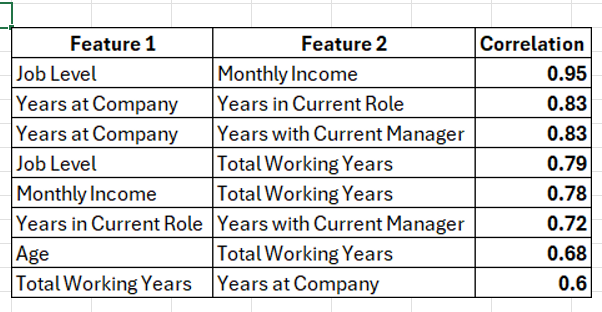

# **6.10 Final Findings**

## Key Insights & Findings



1.  The dataset was validated by checking missing values, duplicate records, data types, and categorical consistency. It was found to be clean and suitable for exploratory data analysis and dashboard development.
2. Employee attrition is imbalanced, with significantly more employees staying than leaving the organization.
3. Employees working overtime show a higher tendency to leave the organization compared to employees who do not work overtime.
4. Employees with lower monthly income generally exhibit a higher tendency toward attrition than higher-income employees.
5. Younger employees appear to have relatively higher attrition than older employees, highlighting the importance of career growth and employee engagement initiatives.
6. The Research & Development department has the largest workforce and records the highest number of employee exits in absolute terms.
7. Job satisfaction and work-life balance appear to be associated with employee retention and should be considered important workforce indicators.
8. Business travel patterns may be associated with employee attrition and can support workforce planning and employee well-being initiatives.
9. Employee experience is strongly associated with job level and monthly income, as reflected by the strong positive correlations among Total Working Years, Job Level, and Monthly Income.
10. The analysis reveals meaningful workforce patterns that can support data-driven HR decision-making, workforce planning, employee retention strategies, API-based workforce applications, and interactive Power BI dashboards.





# **Exploratory Data Analysis Summary**

Exploratory Data Analysis (EDA) was performed to understand workforce characteristics, validate the dataset, and identify factors associated with employee attrition. The analysis included dataset validation, summary statistics, univariate analysis, bivariate analysis, and correlation analysis. Workforce attributes such as age, department, gender, business travel, overtime, job satisfaction, work-life balance, monthly income, and employee experience were explored to identify meaningful trends and relationships.

The analysis suggests that employee attrition is associated with multiple workforce factors, including overtime, monthly income, work-life balance, job satisfaction, age, and employee experience. Strong positive relationships were observed among employee experience, job level, and monthly income, while most other numerical features exhibited weak to moderate correlations, indicating that they contribute unique information to the analysis.

These insights establish a strong foundation for the AI-Powered Workforce Analytics & Talent Intelligence Dashboard, where AI-generated insights, API integration, and interactive Power BI visualizations support data-driven HR decision-making, workforce planning, employee engagement, and retention strategies.

# **Conclusion**

This notebook successfully completed the data validation and Exploratory Data Analysis (EDA) for the AI-Powered Workforce Analytics & Talent Intelligence Dashboard project.

The dataset was validated by checking data quality, handling missing values and duplicate records, verifying data types, and removing unnecessary attributes. The EDA revealed valuable workforce patterns related to employee attrition, compensation, work-life balance, overtime, job satisfaction, age, business travel, and employee experience.

The cleaned dataset and analytical insights generated in this notebook provide a strong foundation for the next phase of the project, where AI-powered insights, API integration, and interactive Power BI dashboards will be used to support workforce analytics, talent intelligence, employee retention strategies, and data-driven HR decision-making.

#**Opportunities**

- Improve employee retention by promoting better work-life balance and employee well-being.
- Strengthen career development and mentorship programs for early-career employees.
- Enhance employee engagement through recognition and continuous feedback initiatives.
- Review compensation strategies to improve retention among lower-income employees.
- Leverage AI-powered analytics and interactive dashboards to support workforce planning and strategic HR decision-making.

#**Risks**

- High overtime may contribute to employee stress and increased attrition.
- Lower job satisfaction and poor work-life balance may negatively affect employee retention.
- Compensation differences across employee groups may influence turnover.
- Frequent business travel may impact employee well-being and retention.
- Younger employees may seek external career growth opportunities, increasing attrition risk.

# **Recommendations**

- Continuously monitor workforce trends using the AI-Powered Workforce Analytics & Talent Intelligence Dashboard.
- Use AI-generated insights to identify workforce patterns and support proactive HR decision-making.
- Review overtime policies and ensure balanced workload distribution across teams.
- Conduct regular employee satisfaction and engagement assessments.
- Invest in employee learning, career development, and retention programs to build a stable and productive workforce.